In [ ]:
# --- Install Library Tambahan ---

!pip install factor_analyzer -q

# --- Import Library ---

# --- Umum ---
import re
from collections import Counter
import numpy as np
import pandas as pd

# --- Visualisasi ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & Machine Learning ---
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import FactorAnalysis
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Analisis Faktor ---
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# --- NLP ---
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# --- Google Colab: Drive ---
from google.colab import drive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 992.3 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# --- Load Dataset dari Google Drive ---

# Path file di Google Drive
file_path = '/content/drive/MyDrive/datasets/dataSuvey - Project UAS Master.xlsx'

drive.mount('/content/drive')
df = pd.read_excel(file_path)
display(df.head())

Mounted at /content/drive


,No,Kecamatan.tempat.tinggal,Kelurahan.tempat.tinggal,Dari.layanan.berikut..pilih.salah.satu.layanan.yang.akan.anda.nilai..layanan.pemerintah.Kota.ABC.yang.pernah.anda.gunakan,TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Kesesuaian.persyaratan.pelayanan.dengan.jenis.pelayanannya.,TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Kesederhanaan.persyaratan.pelayanan.,TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Keterbukaan.mengenai.persyaratan.pelayanan.,TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Kejelasan.mengenai.persyaratan.pelayanan.,TINGKAT.KEPENTINGAN..PROSEDUR.PELAYANAN..Kemudahan.prosedur.pelayanan.,TINGKAT.KEPENTINGAN..PROSEDUR.PELAYANAN..Kejelasan.alur.dalam.prosedur.pelayanan.,...,Tahun.Lahir,Ijazah.terakhir.yang.dimiliki,Pekerjaan,Tempat.bekerja,Kategori.Perwakilan.untuk.menilai.layanan.ini.,Frekuensi.menggunakan.layanan.yang.dinilai,Sumber.utama.informasi.pelayanan.publik,Cara.Perolehan.layanan,Apakah.Anda.bersedia.untuk.dihubungi.kembali.terkait.dengan.survei.ini.,metode.pengumpulan.data
0,1,Tamano,Tama,14. Pelayanan pada Kelurahan,4,4,4,4,4,4,...,1984.0,S1,Guru,Sekolah/Perguruan Tinggi,Perorangan,2-3 kali,Lainnya,Offline,Tidak,Mandiri
1,2,Tamano,Tama,1.1. Pelayanan Kesehatan Dasar (Pusat Kesehata...,4,4,4,4,3,3,...,1984.0,S1,Guru,Sekolah/Perguruan Tinggi,Perorangan,2-3 kali,Lainnya,Offline,Tidak,Mandiri
2,3,Tamano,Tama,1.1. Pelayanan Kesehatan Dasar (Pusat Kesehata...,4,4,4,4,3,3,...,1984.0,S1,guru,Sekolah/Perguruan Tinggi,Perorangan,Lebih dari 5 kali,Lainnya,Offline,Tidak,Mandiri
3,4,Tsushima,Tsushimanaka,8.2. Pelayanan Rambu-rambu Petunjuk Jalan,3,3,3,3,3,3,...,1981.0,SMA,sopir angkot,Usaha masyarakat/non pemerintah,Perorangan,Lebih dari 5 kali,langsung di jalan lalu lintas,Offline,Tidak,Mandiri
4,5,Tamano,Tama,4.2. Pelayanan Pendidikan Dasar,4,4,4,4,4,4,...,1984.0,S1,Guru,Sekolah/Perguruan Tinggi,Perorangan,1 kali,Lainnya,Offline,Tidak,Mandiri


In [ ]:
# --- Cek Nama Semua Kolom pada Dataset Asli ---

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. No
2. Kecamatan.tempat.tinggal
3. Kelurahan.tempat.tinggal
4. Dari.layanan.berikut..pilih.salah.satu.layanan.yang.akan.anda.nilai..layanan.pemerintah.Kota.ABC.yang.pernah.anda.gunakan
5. TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Kesesuaian.persyaratan.pelayanan.dengan.jenis.pelayanannya.
6. TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Kesederhanaan.persyaratan.pelayanan.
7. TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Keterbukaan.mengenai.persyaratan.pelayanan.
8. TINGKAT.KEPENTINGAN..PERSYARATAN.PELAYANAN..Kejelasan.mengenai.persyaratan.pelayanan.
9. TINGKAT.KEPENTINGAN..PROSEDUR.PELAYANAN..Kemudahan.prosedur.pelayanan.
10. TINGKAT.KEPENTINGAN..PROSEDUR.PELAYANAN..Kejelasan.alur.dalam.prosedur.pelayanan.
11. TINGKAT.KEPENTINGAN..PROSEDUR.PELAYANAN..Keterbukaan.informasi.mengenai.prosedur.pelayanan.
12. TINGKAT.KEPENTINGAN..WAKTU.PENYELESAIAN.PELAYANAN..Kecepatan.waktu.dalam.memberikan.pelayanan.
13. TINGKAT.KEPENTINGAN..WAKTU.PENYELESAIAN.PELAYANAN..Keterbukaan.waktu.penyelesaian.p

In [ ]:
# --- Seleksi & Rename Kolom Utama ---

# Nama kolom yang akan di-rename (3 kolom utama)
base_rename_map = {
    'Dari.layanan.berikut..pilih.salah.satu.layanan.yang.akan.anda.nilai..layanan.pemerintah.Kota.ABC.yang.pernah.anda.gunakan': 'layanan',
    'Jika.ada.jenis.indikator.layanan.yang.bapak.ibu.saudara.dirasakan.sangat.tidak.puas.tidak.puas..jelaskan.alasannya.': 'alasan',
    'Saran.Anda.untuk.peningkatan.kualitas.layanan.Organisasi.Perangkat.Daerah..OPD..Pemerintah.Kota.ABC': 'saran'
}

# Kolom yang mengandung indikator kepuasan
kepuasan_cols = [col for col in df.columns if 'TINGKAT.KEPUASAN' in col]

# Kolom final yang dipertahankan
columns_to_keep = list(base_rename_map.keys()) + kepuasan_cols

# Subset + rename
df_preprocessed = df[columns_to_keep].rename(columns=base_rename_map)

# Tampilkan daftar kolom hasil preprocessing
print("--- Daftar Kolom Setelah Preprocessing ---")
for i, col in enumerate(df_preprocessed.columns, start=1):
    print(f"{i}. {col}")

--- Daftar Kolom Setelah Preprocessing ---
1. layanan
2. alasan
3. saran
4. TINGKAT.KEPUASAN..PERSYARATAN.PELAYANAN..Kesesuaian.persyaratan.pelayanan.dengan.jenis.pelayanannya..1
5. TINGKAT.KEPUASAN..PERSYARATAN.PELAYANAN..Kesederhanaan.persyaratan.pelayanan..1
6. TINGKAT.KEPUASAN..PERSYARATAN.PELAYANAN..Keterbukaan.mengenai.persyaratan.pelayanan..1
7. TINGKAT.KEPUASAN..PERSYARATAN.PELAYANAN..Kejelasan.mengenai.persyaratan.pelayanan..1
8. TINGKAT.KEPUASAN..PROSEDUR.PELAYANAN..Kemudahan.prosedur.pelayanan..1
9. TINGKAT.KEPUASAN..PROSEDUR.PELAYANAN..Kejelasan.alur.dalam.prosedur.pelayanan..1
10. TINGKAT.KEPUASAN..PROSEDUR.PELAYANAN..Keterbukaan.informasi.mengenai.prosedur.pelayanan..1
11. TINGKAT.KEPUASAN..WAKTU.PENYELESAIAN.PELAYANAN..Kecepatan.waktu.dalam.memberikan.pelayanan..1
12. TINGKAT.KEPUASAN..WAKTU.PENYELESAIAN.PELAYANAN..Keterbukaan.waktu.penyelesaian.pelayanan..1
13. TINGKAT.KEPUASAN..BIAYA..TARIF.PELAYANAN..Kewajaran.antara.biaya.pelayanan.dengan.hasil.pelayanan..1
14. TINGK

In [ ]:
# --- Fungsi untuk Menyederhanakan Nama Kolom Indikator Kepuasan ---

def simplify_kepuasan_col_name(col_name):

    # Lewati kolom non-kepuasan
    if col_name in ['layanan', 'alasan', 'saran']:
        return col_name

    # Hilangkan prefix standar
    name = col_name
    if name.startswith('TINGKAT.KEPUASAN..'):
        name = name.replace('TINGKAT.KEPUASAN..', '', 1)

    # Hard mapping
    if name.startswith('Kemudahan.menggunakan.website'):
        return 'kepuasan_website_kemudahan'
    elif name.startswith('Kelengkapan.fitur.website'):
        return 'kepuasan_website_kelengkapan_fitur'
    elif name.startswith('Pedoman.yang.user.friendly'):
        return 'kepuasan_website_pedoman'
    elif name.startswith('Adanya.bantuan.online.dalam.formulir'):
        return 'kepuasan_website_bantuan_online'
    elif name.startswith('Kemampuan.pelayanan.tepat.waktu'):
        return 'kepuasan_pelayanan_tepat_waktu'
    elif name.startswith('Kelengkapan.dan.keakuratan.data.informasi'):
        return 'kepuasan_data_keakuratan'

    # Cleanup umum
    name = re.sub(r'\.{2}1$', '', name)
    name = re.sub(r'\.{2,}', '.', name).lower()

    category = None
    aspect = None

    # Kategorisasi berdasarkan prefix pola umum
    if name.startswith('penanganan.pengaduan.saran.masukan'):
        category = 'penanganan'
        if 'tindak.lanjut' in name:
            aspect = 'tindak_lanjut'
        elif 'tata.cara' in name:
            aspect = 'tata_cara'
        else:
            aspect = 'pengaduan'

    elif name.startswith('persyaratan.pelayanan'):
        category = 'persyaratan'
        match = re.search(r'persyaratan\.pelayanan\.([^.]+)', name)
        if match: aspect = match.group(1)

    elif name.startswith('prosedur.pelayanan'):
        category = 'prosedur'
        match = re.search(r'prosedur\.pelayanan\.([^.]+)', name)
        if match: aspect = match.group(1)

    elif name.startswith('waktu.penyelesaian.pelayanan'):
        category = 'waktu'
        match = re.search(r'waktu\.penyelesaian\.pelayanan\.([^.]+)', name)
        if match: aspect = match.group(1)

    elif name.startswith('biaya.tarif.pelayanan'):
        category = 'biaya'
        match = re.search(r'biaya\.tarif\.pelayanan\.([^.]+)', name)
        if match: aspect = match.group(1)

    elif name.startswith('produk.spesifikasi.jenis.pelayanan'):
        category = 'produk'
        match = re.search(r'produk\.spesifikasi\.jenis\.pelayanan\.([^.]+)', name)
        if match: aspect = match.group(1)

    elif name.startswith('kompetensi.pelaksana'):
        category = 'kompetensi'
        if 'kemampuan' in name:
            aspect = 'kemampuan'
        else:
            match = re.search(r'kompetensi\.pelaksana\.([^.]+)', name)
            if match: aspect = match.group(1)

    elif name.startswith('perilaku.pelaksana'):
        category = 'perilaku'
        match = re.search(r'perilaku\.pelaksana\.([^.]+)', name)
        if match: aspect = match.group(1)

    elif name.startswith('sarana.prasarana'):
        category = 'sarana'
        match = re.search(r'sarana\.prasarana\.([^.]+)', name)
        aspect = match.group(1) if match else 'prasarana'

    # Format final nama kolom
    if category and aspect:
        return f'kepuasan_{category}_{aspect}'
    elif category:
        return f'kepuasan_{category}'
    else:
        clean = re.sub(r'\W+', '_', name).strip('_')
        return f'kepuasan_{clean}' if clean else 'kepuasan_unknown'


# Dictionary rename otomatis untuk seluruh kolom kepuasan
kepuasan_rename_map = {
    col: simplify_kepuasan_col_name(col)
    for col in df_preprocessed.columns
    if 'TINGKAT.KEPUASAN' in col
}

# Rename kolom pada dataframe
df_preprocessed = df_preprocessed.rename(columns=kepuasan_rename_map)

# Cek kolom hasil preprocessing
for col in df_preprocessed.columns:
    print(col)

layanan
alasan
saran
kepuasan_persyaratan_kesesuaian
kepuasan_persyaratan_kesederhanaan
kepuasan_persyaratan_keterbukaan
kepuasan_persyaratan_kejelasan
kepuasan_prosedur_kemudahan
kepuasan_prosedur_kejelasan
kepuasan_prosedur_keterbukaan
kepuasan_waktu_kecepatan
kepuasan_waktu_keterbukaan
kepuasan_biaya_kewajaran
kepuasan_biaya_kejelasan
kepuasan_biaya_keterbukaan
kepuasan_produk_kesuaian
kepuasan_kompetensi_kemampuan
kepuasan_kompetensi_pengetahuan
kepuasan_kompetensi_keterampilan
kepuasan_kompetensi_pengalaman
kepuasan_perilaku_kesopanan
kepuasan_perilaku_kesamaan
kepuasan_sarana_kualitas
kepuasan_sarana_kebersihan
kepuasan_sarana_kelengkapan
kepuasan_penanganan_pengaduan
kepuasan_penanganan_tata_cara
kepuasan_penanganan_tindak_lanjut
kepuasan_website_kemudahan
kepuasan_website_kelengkapan_fitur
kepuasan_website_pedoman
kepuasan_website_bantuan_online
kepuasan_pelayanan_tepat_waktu
kepuasan_kelengkapan_dan_keakuratan_data_informasi


In [ ]:
# --- Cek Isi Unik pada Kolom 'layanan' ---

unique_layanan = df_preprocessed['layanan'].unique()

print("Daftar layanan unik:")
for item in unique_layanan:
    print(f"- {item}")

Daftar layanan unik:
- 14. Pelayanan pada Kelurahan
- 1.1. Pelayanan Kesehatan Dasar (Pusat Kesehatan Masyarakat/Puskesmas)
- 8.2. Pelayanan Rambu-rambu Petunjuk Jalan
- 4.2. Pelayanan Pendidikan Dasar
- 8.4. Pelayanan Lampu Lalu Lintas
- 4.3. Pelayanan Pendidikan Menengah
- 12.1. Pelayanan Pembayaran PBB
- 4.1. Pelayanan TK/ PAUD
- 8.3. Pelayanan Penerangan Jalan Umum (PJU)
- 5.2. Jalan Lingkungan
- 9.1. Pelayanan Akte Kelahiran
- 9.3. Pelayanan KK
- 9.2. Pelayanan KTP
- 6.1. Pelayanan Persampahan Bagi Masyarakat
- 7. Pelayanan Kartu Kuning
- 2.1. Pelayanan Lanjutan RSUD Bag. Laboratorium
- 2.2. Pelayanan Lanjutan RSUD Bag. Pendaftaran
- 2.3. Pelayanan Lanjutan RSUD Bag. IGD
- 2.4. Pelayanan Lanjutan RSUD Bag. Bersalin
- 2.5. Pelayanan Lanjutan RSUD Bag. BPJS Kesehatan
- 2.6. Pelayanan Lanjutan RSUD Bag. Rawat Inap
- 2.8. Pelayanan Lanjutan RSUD Bag. Radiologi
- 2.9. Pelayanan Lanjutan RSUD Bag. Farmasi
- 2.10. Pelayanan Lanjutan RSUD Bag. Rawat Jalan
- 2.7. Pelayanan Lanjutan RSUD Ba

In [ ]:
# --- Mapping Kategori Layanan ke Nama yang Lebih Umum ---

category_mapping = {
    '1':  'Pelayanan Kesehatan Dasar',
    '2':  'Pelayanan Lanjutan RSUD',
    '3':  'Pelayanan Perizinan',
    '4':  'Pelayanan Pendidikan',
    '5':  'Pelayanan Jalan',
    '6':  'Pelayanan Persampahan & Limbah',
    '7':  'Pelayanan Kartu Kuning',
    '8':  'Pelayanan Lalu Lintas & Penerangan',
    '9':  'Pelayanan Administrasi Kependudukan',
    '10': 'Pelayanan Hewan',
    '11': 'Pelayanan Pasar',
    '12': 'Pelayanan Pembayaran Pajak',
    '13': 'Pelayanan Pemadam Kebakaran & Penyelamatan',
    '14': 'Pelayanan pada Kelurahan'
}

In [ ]:
# --- Ekstraksi Nomor Layanan dari String ---

# Fungsi untuk mengekstrak nomor layanan di awal string
def extract_no_layanan(layanan_str):
    if isinstance(layanan_str, str):
        match = re.match(r'^(\d+)', layanan_str.strip())
        if match:
            return match.group(1)
    return None

# Tambahkan kolom nomor layanan ke dataframe
df_preprocessed['no_layanan'] = df_preprocessed['layanan'].apply(extract_no_layanan)

# Cek hasil ekstraksi nomor layanan
print("\n--- Hasil Ekstraksi Nomor Layanan ---")
display(df_preprocessed[['no_layanan', 'layanan']].head())


--- Hasil Ekstraksi Nomor Layanan ---


,no_layanan,layanan
0,14,14. Pelayanan pada Kelurahan
1,1,1.1. Pelayanan Kesehatan Dasar (Pusat Kesehata...
2,1,1.1. Pelayanan Kesehatan Dasar (Pusat Kesehata...
3,8,8.2. Pelayanan Rambu-rambu Petunjuk Jalan
4,4,4.2. Pelayanan Pendidikan Dasar


In [ ]:
# --- Mapping Nomor Layanan Menjadi Kategori Umum ---

# Update kolom 'layanan' menggunakan dictionary mapping
df_preprocessed['layanan'] = df_preprocessed['no_layanan'].map(category_mapping)

# Cek hasil mapping
print("\n--- Kolom 'layanan' Setelah Diperbarui ---")
display(df_preprocessed[['no_layanan', 'layanan']].head())


--- Kolom 'layanan' Setelah Diperbarui ---


,no_layanan,layanan
0,14,Pelayanan pada Kelurahan
1,1,Pelayanan Kesehatan Dasar
2,1,Pelayanan Kesehatan Dasar
3,8,Pelayanan Lalu Lintas & Penerangan
4,4,Pelayanan Pendidikan


In [ ]:
# --- Analisis Missing Value pada Kolom Kepuasan ---

# Ambil semua kolom kepuasan
kepuasan_cols_current = [col for col in df_preprocessed.columns if col.startswith('kepuasan_')]

# Hitung jumlah & persentase missing value
missing_counts = df_preprocessed[kepuasan_cols_current].isnull().sum()
missing_percentage = (missing_counts / len(df_preprocessed)) * 100

# Tampilkan hasil
print("\n--- Persentase Missing Values pada Kolom Kepuasan ---")
print(missing_percentage.sort_values(ascending=False))


--- Persentase Missing Values pada Kolom Kepuasan ---
kepuasan_website_kemudahan                            46.041934
kepuasan_website_pedoman                              45.956354
kepuasan_website_kelengkapan_fitur                    45.913564
kepuasan_website_bantuan_online                       45.614035
kepuasan_pelayanan_tepat_waktu                        45.442875
kepuasan_kelengkapan_dan_keakuratan_data_informasi    45.357296
kepuasan_penanganan_tindak_lanjut                     20.453573
kepuasan_penanganan_pengaduan                         20.367993
kepuasan_penanganan_tata_cara                         20.154044
kepuasan_kompetensi_kemampuan                          1.369277
kepuasan_sarana_kelengkapan                            1.240907
kepuasan_sarana_kualitas                               1.240907
kepuasan_kompetensi_pengalaman                         1.240907
kepuasan_kompetensi_pengetahuan                        1.112537
kepuasan_perilaku_kesamaan                       

In [ ]:
# --- Drop Kolom Kepuasan dengan Missing Value > 40% ---

# Identifikasi kolom yang perlu di-drop
columns_to_drop_now = missing_percentage[missing_percentage > 40].index.tolist()

# Drop kolom
df_preprocessed = df_preprocessed.drop(columns=columns_to_drop_now, errors='ignore')

# Cek kembali persentase missing values setelah drop
kepuasan_cols_after_drop = [
    col for col in df_preprocessed.columns
    if col.startswith('kepuasan_')
]

missing_after_drop = df_preprocessed[kepuasan_cols_after_drop].isnull().sum()
missing_percentage_after_drop = (missing_after_drop / len(df_preprocessed)) * 100

# Output hasil
print("\n--- Persentase Missing Values Kolom Kepuasan Setelah Drop ---")
print(missing_percentage_after_drop.sort_values(ascending=False))


--- Persentase Missing Values Kolom Kepuasan Setelah Drop ---
kepuasan_penanganan_tindak_lanjut     20.453573
kepuasan_penanganan_pengaduan         20.367993
kepuasan_penanganan_tata_cara         20.154044
kepuasan_kompetensi_kemampuan          1.369277
kepuasan_sarana_kualitas               1.240907
kepuasan_kompetensi_pengalaman         1.240907
kepuasan_sarana_kelengkapan            1.240907
kepuasan_kompetensi_pengetahuan        1.112537
kepuasan_perilaku_kesamaan             1.069748
kepuasan_sarana_kebersihan             0.984168
kepuasan_kompetensi_keterampilan       0.898588
kepuasan_perilaku_kesopanan            0.855798
kepuasan_waktu_keterbukaan             0.000000
kepuasan_prosedur_kemudahan            0.000000
kepuasan_persyaratan_kejelasan         0.000000
kepuasan_persyaratan_keterbukaan       0.000000
kepuasan_persyaratan_kesederhanaan     0.000000
kepuasan_persyaratan_kesesuaian        0.000000
kepuasan_waktu_kecepatan               0.000000
kepuasan_prosedur_keterbu

In [ ]:
# --- Imputasi Missing Values pada Kolom Kepuasan ---

# Daftar kolom kepuasan yang masih memiliki missing value
kepuasan_cols_to_impute = [
    col for col in df_preprocessed.columns
    if col.startswith('kepuasan_') and df_preprocessed[col].isnull().any()
]

# Imputasi menggunakan KNN Imputer
if kepuasan_cols_to_impute:
    imputer = KNNImputer(n_neighbors=10)
    df_preprocessed[kepuasan_cols_to_impute] = imputer.fit_transform(
        df_preprocessed[kepuasan_cols_to_impute]
    )

# Hitung kembali missing values setelah imputasi
all_kepuasan_cols = [
    col for col in df_preprocessed.columns
    if col.startswith('kepuasan_')
]

final_missing = df_preprocessed[all_kepuasan_cols].isnull().sum()
final_missing_percentage = (final_missing / len(df_preprocessed)) * 100

# Output hasil
print("\n--- Persentase Missing Values Kolom Kepuasan Setelah Imputasi ---")
print(final_missing_percentage.sort_values(ascending=False))


--- Persentase Missing Values Kolom Kepuasan Setelah Imputasi ---
kepuasan_persyaratan_kesesuaian       0.0
kepuasan_persyaratan_kesederhanaan    0.0
kepuasan_persyaratan_keterbukaan      0.0
kepuasan_persyaratan_kejelasan        0.0
kepuasan_prosedur_kemudahan           0.0
kepuasan_prosedur_kejelasan           0.0
kepuasan_prosedur_keterbukaan         0.0
kepuasan_waktu_kecepatan              0.0
kepuasan_waktu_keterbukaan            0.0
kepuasan_biaya_kewajaran              0.0
kepuasan_biaya_kejelasan              0.0
kepuasan_biaya_keterbukaan            0.0
kepuasan_produk_kesuaian              0.0
kepuasan_kompetensi_kemampuan         0.0
kepuasan_kompetensi_pengetahuan       0.0
kepuasan_kompetensi_keterampilan      0.0
kepuasan_kompetensi_pengalaman        0.0
kepuasan_perilaku_kesopanan           0.0
kepuasan_perilaku_kesamaan            0.0
kepuasan_sarana_kualitas              0.0
kepuasan_sarana_kebersihan            0.0
kepuasan_sarana_kelengkapan           0.0
kepuasan_

In [ ]:
# --- Agregasi Indikator Kepuasan Menjadi Kelompok Utama ---

# Kolom non-kepuasan yang ingin dipertahankan
non_kepuasan_cols = ['no_layanan', 'layanan', 'alasan', 'saran']
final_df = df_preprocessed[non_kepuasan_cols].copy()

# Ambil semua kolom indikator kepuasan
kepuasan_cols = [
    col for col in df_preprocessed.columns
    if col.startswith('kepuasan_')
]

# Dictionary kelompok agregasi
groups_for_aggregation = {}

# Kelompokkan berdasarkan kategori utama (contoh: kepuasan_prosedur_x → kepuasan_prosedur)
for col in kepuasan_cols:
    parts = col.split('_')
    if len(parts) > 1:
        main_category = parts[1]
        aggregated_name = f"kepuasan_{main_category}"
        groups_for_aggregation.setdefault(aggregated_name, []).append(col)

# Tambahkan kolom agregasi ke final_df dengan nilai mean setiap kelompok
for aggregated_name, detail_cols in groups_for_aggregation.items():
    final_df[aggregated_name] = df_preprocessed[detail_cols].mean(axis=1)

# Update df_preprocessed
df_preprocessed = final_df.copy()

# Cek hasil agregasi
print("\n--- Kolom Setelah Agregasi Indikator Kepuasan ---")
for col in df_preprocessed.columns:
    print(col)


--- Kolom Setelah Agregasi Indikator Kepuasan ---
no_layanan
layanan
alasan
saran
kepuasan_persyaratan
kepuasan_prosedur
kepuasan_waktu
kepuasan_biaya
kepuasan_produk
kepuasan_kompetensi
kepuasan_perilaku
kepuasan_sarana
kepuasan_penanganan


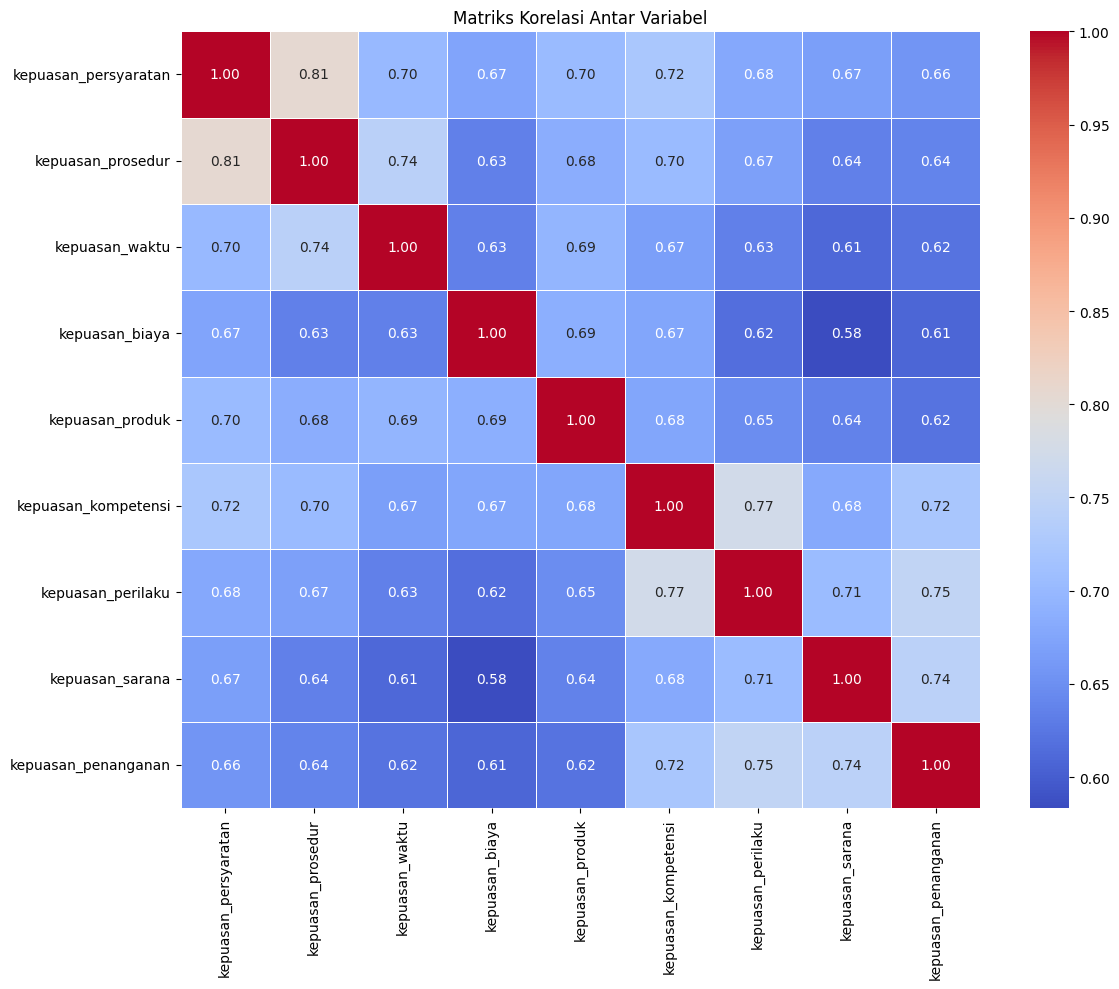


=== Interpretasi Matriks Korelasi ===

• Secara umum, seluruh variabel kepuasan menunjukkan korelasi positif sedang hingga kuat 
  (0.58 – 0.81). Ini menandakan bahwa berbagai aspek pelayanan saling berhubungan:
  peningkatan pada satu aspek cenderung diikuti oleh peningkatan aspek lainnya.

• Tidak terdapat korelasi rendah (< 0.40), sehingga semua variabel masih relevan 
  untuk dilibatkan dalam analisis lanjutan seperti Analisis Faktor atau Clustering.


=== Korelasi Tertinggi ===
1. kepuasan_persyaratan ↔ kepuasan_prosedur (0.81)
   → Persyaratan dan prosedur pelayanan merupakan bagian dari satu alur proses,
     sehingga kepuasan pada keduanya bergerak searah dan konsisten.

2. kepuasan_kompetensi ↔ kepuasan_perilaku (0.77)
   → Petugas yang kompeten umumnya juga dinilai berperilaku baik.
     Ini mencerminkan kualitas SDM yang kuat.

3. kepuasan_sarana ↔ kepuasan_penanganan (0.74)
   → Sarana yang memadai mendukung penanganan pengaduan yang lebih baik.


=== Korelasi Terendah (te

In [ ]:
# --- Matriks Korelasi Antar Variabel ---

# Hitung matriks korelasi hanya pada kolom numerik
correlation_matrix = df_preprocessed.corr(numeric_only=True)

# Visualisasi heatmap korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriks Korelasi Antar Variabel")
plt.tight_layout()
plt.show()


# --- Interpretasi Matriks Korelasi Kepuasan Layanan ---

print("""
=== Interpretasi Matriks Korelasi ===

• Secara umum, seluruh variabel kepuasan menunjukkan korelasi positif sedang hingga kuat
  (0.58 – 0.81). Ini menandakan bahwa berbagai aspek pelayanan saling berhubungan:
  peningkatan pada satu aspek cenderung diikuti oleh peningkatan aspek lainnya.

• Tidak terdapat korelasi rendah (< 0.40), sehingga semua variabel masih relevan
  untuk dilibatkan dalam analisis lanjutan seperti Analisis Faktor atau Clustering.


=== Korelasi Tertinggi ===
1. kepuasan_persyaratan ↔ kepuasan_prosedur (0.81)
   → Persyaratan dan prosedur pelayanan merupakan bagian dari satu alur proses,
     sehingga kepuasan pada keduanya bergerak searah dan konsisten.

2. kepuasan_kompetensi ↔ kepuasan_perilaku (0.77)
   → Petugas yang kompeten umumnya juga dinilai berperilaku baik.
     Ini mencerminkan kualitas SDM yang kuat.

3. kepuasan_sarana ↔ kepuasan_penanganan (0.74)
   → Sarana yang memadai mendukung penanganan pengaduan yang lebih baik.


=== Korelasi Terendah (tetap positif) ===
• kepuasan_biaya ↔ kepuasan_sarana (0.58)
• kepuasan_biaya ↔ kepuasan_penanganan (0.61)

  → Aspek biaya/tarif lebih berdiri sendiri dan tidak banyak dipengaruhi sarana
    maupun penanganan langsung.


=== Kesimpulan Utama ===
• Struktur korelasi yang kuat antar variabel menunjukkan data sangat mendukung
  untuk Analisis Faktor. Kemungkinan besar terdapat beberapa dimensi laten
  (misalnya: kualitas proses, kualitas SDM, fasilitas) yang menjelaskan pola ini.

• Temuan ini juga menunjukkan bahwa responden menilai kualitas layanan secara holistik:
  kelemahan pada satu aspek dapat menurunkan persepsi terhadap aspek lainnya.
""")

In [ ]:
# --- Uji KMO & Bartlett untuk Kelayakan Analisis Faktor ---

# Dataset khusus variabel kepuasan
df_kepuasan = df_preprocessed[
    [col for col in df_preprocessed.columns if col.startswith('kepuasan_')]
].dropna()

print("\n=== Uji KMO & Bartlett ===")

# Hitung nilai KMO
kmo_all, kmo_model = calculate_kmo(df_kepuasan)
print(f"KMO Model: {kmo_model:.4f}")

# Hitung uji Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_kepuasan)
print(f"Bartlett Chi-square: {chi_square_value:.4f}")
print(f"Bartlett p-value: {p_value:.6f}")


# --- Interpretasi Hasil Uji ---
print("\n=== Interpretasi ===")

# Interpretasi KMO
if kmo_model >= 0.80:
    print("✓ Nilai KMO sangat baik (>= 0.80). Data sangat layak untuk analisis faktor.")
elif kmo_model >= 0.70:
    print("✓ Nilai KMO baik (>= 0.70). Data layak digunakan untuk analisis faktor.")
elif kmo_model >= 0.60:
    print("✓ Nilai KMO cukup (>= 0.60). Analisis faktor masih dapat dilanjutkan.")
else:
    print("✗ Nilai KMO < 0.60. Data kurang layak untuk analisis faktor.")

# Interpretasi Bartlett
if p_value < 0.05:
    print("✓ Uji Bartlett signifikan (p < 0.05). Terdapat korelasi yang memadai antar variabel.")
    print("  → Data memenuhi asumsi untuk dilakukan analisis faktor.")
else:
    print("✗ Uji Bartlett tidak signifikan. Korelasi antar variabel belum memadai.")


=== Uji KMO & Bartlett ===
KMO Model: 0.9474
Bartlett Chi-square: 17905.8626
Bartlett p-value: 0.000000

=== Interpretasi ===
✓ Nilai KMO sangat baik (>= 0.80). Data sangat layak untuk analisis faktor.
✓ Uji Bartlett signifikan (p < 0.05). Terdapat korelasi yang memadai antar variabel.
  → Data memenuhi asumsi untuk dilakukan analisis faktor.


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


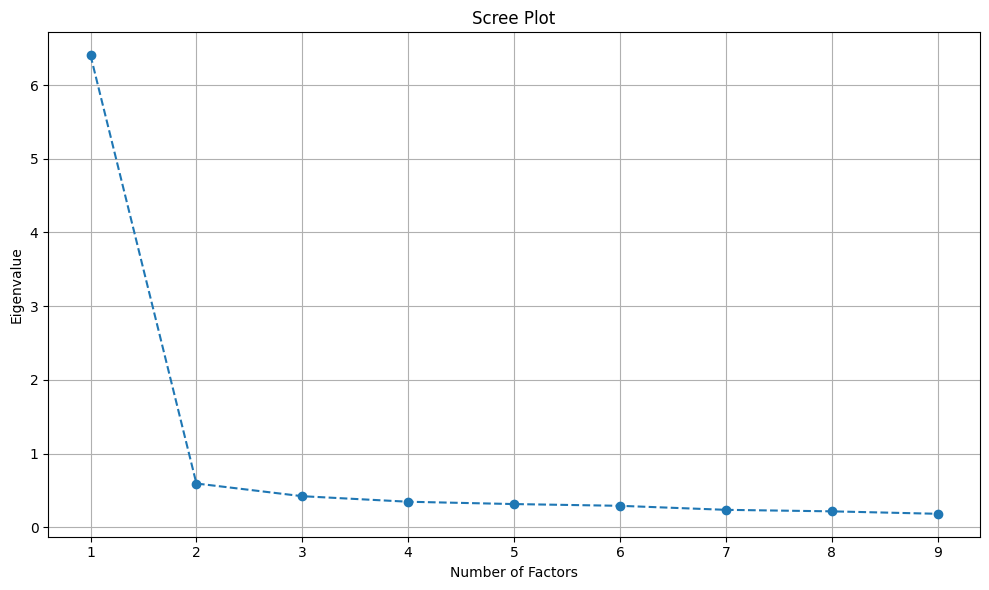


Berdasarkan pola scree plot, setelah faktor kedua kurva mulai menunjukkan pola 
pelandaian. Hal ini mengindikasikan bahwa kontribusi informasi tambahan 
setelah faktor kedua tidak terlalu signifikan.

Dengan demikian, jumlah faktor yang sesuai untuk digunakan dalam analisis 
adalah **dua faktor**.



In [ ]:
# --- Scree Plot untuk Menentukan Jumlah Faktor ---

# Ambil hanya kolom yang berkaitan dengan kepuasan
kepuasan_cols = [col for col in df_preprocessed.columns if col.startswith('kepuasan_')]
df_kepuasan = df_preprocessed[kepuasan_cols].copy()

# Hitung eigenvalue dari matriks korelasi
corr_matrix_kepuasan = df_kepuasan.corr()
eigenvalues = np.linalg.eigvals(corr_matrix_kepuasan)
eigenvalues = np.sort(eigenvalues)[::-1]  # urutkan dari terbesar

# Plot Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker='o',
    linestyle='--'
)
plt.title('Scree Plot')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.tight_layout()
plt.show()

# --- Interpretasi Scree Plot ---
print("""
Berdasarkan pola scree plot, setelah faktor kedua kurva mulai menunjukkan pola
pelandaian. Hal ini mengindikasikan bahwa kontribusi informasi tambahan
setelah faktor kedua tidak terlalu signifikan.

Dengan demikian, jumlah faktor yang sesuai untuk digunakan dalam analisis
adalah **dua faktor**.
""")

In [ ]:
# --- Factor Loadings: Tanpa Rotasi ---
kepuasan_cols = [col for col in df_preprocessed.columns if col.startswith('kepuasan_')]
df_kepuasan = df_preprocessed[kepuasan_cols].copy()

# Standarisasi
scaler = StandardScaler()
df_kepuasan_scaled = scaler.fit_transform(df_kepuasan)

# Analisis faktor awal (no rotation)
fa = FactorAnalyzer(n_factors=2, rotation=None, method='minres')
fa.fit(df_kepuasan_scaled)

factor_loadings = pd.DataFrame(
    fa.loadings_,
    index=kepuasan_cols,
    columns=[f'faktor{i+1}' for i in range(2)]
)

print("Factor Loadings (tanpa rotasi):")
display(factor_loadings)

print("\n=== Interpretasi (tanpa rotasi) ===")
print("""
- Hampir semua indikator punya loading tinggi di Faktor 1 (0.77–0.86).
  Artinya ada satu faktor besar yang mendominasi, mencerminkan
  'kepuasan layanan secara umum'.

- Faktor 2 masih lemah dan belum terlihat pola yang jelas (loading kecil
  dan acak). Hal ini normal karena tanpa rotasi struktur faktor cenderung
  belum terpisah dengan baik.

- Dimensi:
    • Faktor 1 = faktor umum kepuasan.
    • Faktor 2 = belum bisa diinterpretasi (butuh rotasi).
""")

Factor Loadings (tanpa rotasi):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,faktor1,faktor2
kepuasan_persyaratan,0.859849,0.176947
kepuasan_prosedur,0.846745,0.222702
kepuasan_waktu,0.807345,0.182026
kepuasan_biaya,0.769833,0.091459
kepuasan_produk,0.810950,0.129542
kepuasan_kompetensi,0.856978,-0.085221
kepuasan_perilaku,0.839864,-0.216036
kepuasan_sarana,0.800833,-0.196587
kepuasan_penanganan,0.827236,-0.303698



=== Interpretasi (tanpa rotasi) ===

- Hampir semua indikator punya loading tinggi di Faktor 1 (0.77–0.86). 
  Artinya ada satu faktor besar yang mendominasi, mencerminkan 
  'kepuasan layanan secara umum'.

- Faktor 2 masih lemah dan belum terlihat pola yang jelas (loading kecil 
  dan acak). Hal ini normal karena tanpa rotasi struktur faktor cenderung 
  belum terpisah dengan baik.

- Dimensi:
    • Faktor 1 = faktor umum kepuasan.
    • Faktor 2 = belum bisa diinterpretasi (butuh rotasi).



In [ ]:
# --- Factor Loadings Dengan Rotasi Varimax ---
fa = FactorAnalyzer(n_factors=2, rotation='varimax', method='minres')
fa.fit(df_kepuasan_scaled)

rotated_loadings = pd.DataFrame(
    fa.loadings_,
    index=kepuasan_cols,
    columns=[f'faktor{i+1}' for i in range(2)]
)

print("Factor Loadings (dengan rotasi Varimax):")
display(rotated_loadings)

print("\n=== Interpretasi Factor Loadings (Rotasi Varimax) ===")
print("""
1) **Faktor 1 – Kualitas Proses Pelayanan**
   Loading tinggi pada:
   - persyaratan (0.75)
   - prosedur    (0.77)
   - waktu       (0.72)
   - biaya       (0.63)
   - produk      (0.69)

2) **Faktor 2 – Kualitas SDM & Dukungan**
   Loading tinggi pada:
   - kompetensi  (0.64)
   - perilaku    (0.73)
   - sarana      (0.69)
   - penanganan  (0.78)

Dimensi:
- Faktor 1 = kualitas proses.
- Faktor 2 = kualitas SDM & dukungan.
""")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor Loadings (dengan rotasi Varimax):


,faktor1,faktor2
kepuasan_persyaratan,0.754023,0.449555
kepuasan_prosedur,0.775223,0.406943
kepuasan_waktu,0.718698,0.410382
kepuasan_biaya,0.629904,0.451917
kepuasan_produk,0.685947,0.451551
kepuasan_kompetensi,0.575015,0.641117
kepuasan_perilaku,0.474120,0.726122
kepuasan_sarana,0.458435,0.685432
kepuasan_penanganan,0.405652,0.782303



=== Interpretasi Factor Loadings (Rotasi Varimax) ===

1) **Faktor 1 – Kualitas Proses Pelayanan**
   Loading tinggi pada:
   - persyaratan (0.75)
   - prosedur    (0.77)
   - waktu       (0.72)
   - biaya       (0.63)
   - produk      (0.69)

2) **Faktor 2 – Kualitas SDM & Dukungan**
   Loading tinggi pada:
   - kompetensi  (0.64)
   - perilaku    (0.73)
   - sarana      (0.69)
   - penanganan  (0.78)

Dimensi:
- Faktor 1 = kualitas proses.
- Faktor 2 = kualitas SDM & dukungan.



In [ ]:
# --- Menghitung Factor Score (Skor Faktor per Responden) ---

# Ambil kolom kepuasan
kepuasan_cols_for_fa = [col for col in df_preprocessed.columns if col.startswith('kepuasan_')]
df_kepuasan_for_fa = df_preprocessed[kepuasan_cols_for_fa].copy()

# Standarisasi data
scaler_for_factor = StandardScaler()
df_kepuasan_scaled_for_fa = scaler_for_factor.fit_transform(df_kepuasan_for_fa)

# Hitung factor scores menggunakan model FA yang telah di-fit sebelumnya
factor_scores = fa.transform(df_kepuasan_scaled_for_fa)

# Simpan ke dataframe
factor_scores_df = pd.DataFrame(
    factor_scores,
    index=df_preprocessed.index,
    columns=['factor1_score', 'factor2_score']
)

# Gabungkan kembali ke dataset utama
df_preprocessed = df_preprocessed.join(factor_scores_df)

# Tampilkan sebagian hasil
display(df_preprocessed.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,no_layanan,layanan,alasan,saran,kepuasan_persyaratan,kepuasan_prosedur,kepuasan_waktu,kepuasan_biaya,kepuasan_produk,kepuasan_kompetensi,kepuasan_perilaku,kepuasan_sarana,kepuasan_penanganan,factor1_score,factor2_score
0,14,Pelayanan pada Kelurahan,-,"Tingkatkan Ramah, Jujur, Terbuka terhadap pela...",3.5,3.666667,4.0,2.666667,4.0,4.00,4.00,3.666667,4.0,0.062970,1.072033
1,1,Pelayanan Kesehatan Dasar,-,-,4.0,3.666667,3.0,4.000000,4.0,4.00,1.00,2.666667,2.0,2.013500,-2.731763
2,1,Pelayanan Kesehatan Dasar,-,-,4.0,3.666667,3.0,4.000000,4.0,4.00,1.00,2.666667,2.0,2.013500,-2.731763
3,8,Pelayanan Lalu Lintas & Penerangan,"-Jalan banyak yang berlubang, rambu-rambu petu...",-Mekanisme kinerja dishub dan polantas tidak m...,3.0,1.000000,1.0,1.000000,1.0,1.00,1.75,2.000000,1.6,-2.804271,-1.782734
4,4,Pelayanan Pendidikan,-,Fasilitas ditingkatkan,4.0,4.000000,4.0,3.333333,4.0,3.25,3.50,3.666667,4.0,0.824394,0.296770


In [ ]:
# --- Agregasi per Layanan untuk K-Means Cluster ---

# Ambil semua kolom yang mengandung skor kepuasan
kepuasan_cols = [col for col in df_preprocessed.columns if col.startswith('kepuasan_')]

# Hitung skor kepuasan total (rata-rata seluruh aspek)
df_preprocessed['kepuasan_total'] = df_preprocessed[kepuasan_cols].mean(axis=1)

# Kolom yang dipakai untuk clustering (level layanan)
columns_for_df_cluster = [
    'no_layanan',
    'layanan',
    'kepuasan_total',
    'factor1_score',
    'factor2_score'
]

# Agregasi rata-rata per layanan
df_cluster = (
    df_preprocessed[columns_for_df_cluster]
    .groupby(['no_layanan', 'layanan'])
    .mean()
    .reset_index()
)

print("Data agregasi per layanan (mean kepuasan_total dan faktor score):")
display(df_cluster.head())

Data agregasi per layanan (mean kepuasan_total dan faktor score):


,no_layanan,layanan,kepuasan_total,factor1_score,factor2_score
0,1,Pelayanan Kesehatan Dasar,3.297537,0.037372,-0.139812
1,10,Pelayanan Hewan,3.394152,0.163131,-0.022934
2,11,Pelayanan Pasar,2.994155,-0.403083,-0.475181
3,12,Pelayanan Pembayaran Pajak,3.378885,0.007551,0.119073
4,13,Pelayanan Pemadam Kebakaran & Penyelamatan,3.436155,-0.069837,0.353110


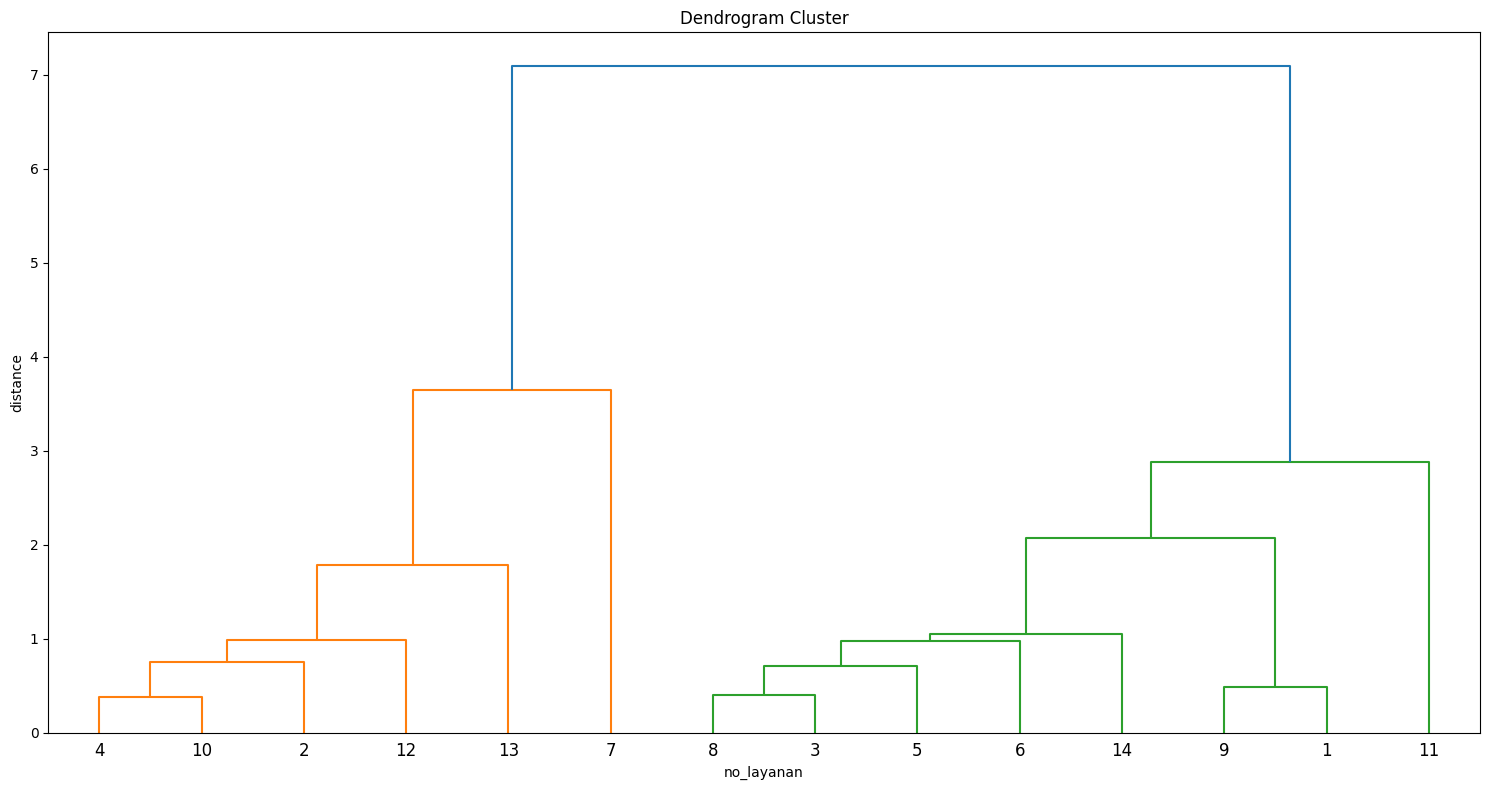

In [ ]:
# --- Dendrogram untuk Melihat Struktur Cluster ---

# Pilih variabel yang dipakai untuk clustering
X_cluster = df_cluster[['kepuasan_total', 'factor1_score', 'factor2_score']].copy()

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Hierarchical clustering (Ward linkage)
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    linked,
    orientation='top',
    labels=df_cluster['no_layanan'].tolist(),
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrogram Cluster')
plt.xlabel('no_layanan')
plt.ylabel('distance')
plt.tight_layout()
plt.show()

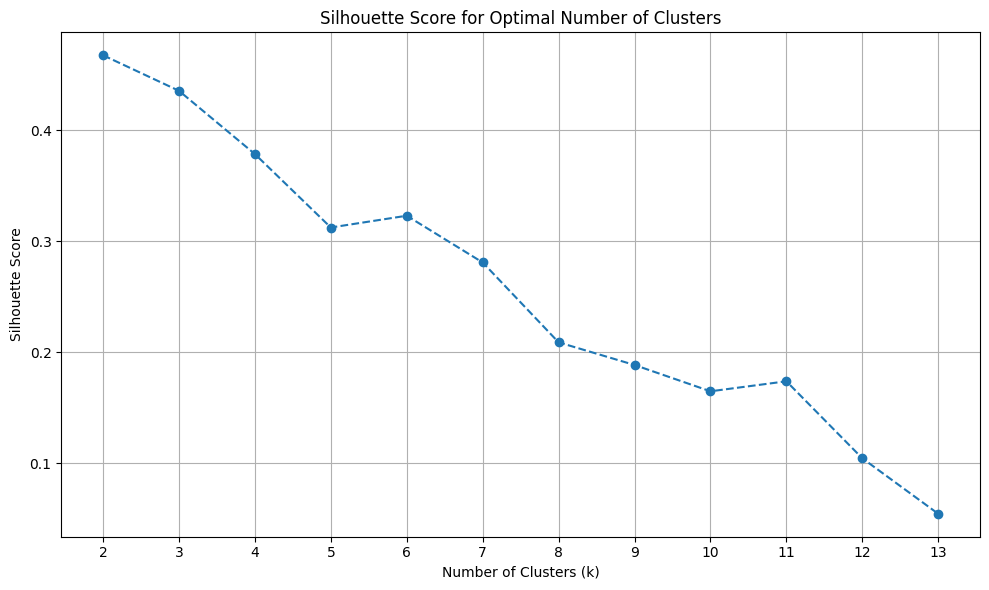

Optimal number of clusters (Silhouette): 2


In [ ]:
# --- Silhouette Analysis untuk Menentukan Jumlah Cluster Optimal ---

# Pastikan X_scaled sudah tersedia
if 'X_scaled' not in locals():
    print("X_scaled not found. Re-running data scaling...")
    X_cluster = df_cluster[['kepuasan_total', 'factor1_score', 'factor2_score']].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

# Rentang jumlah cluster (minimal 2 cluster)
range_n_clusters = range(2, len(df_cluster))

silhouette_scores = []

# Hitung silhouette score untuk setiap k
for k in range_n_clusters:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        random_state=108,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# --- Plot Silhouette Score ---
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range_n_clusters)
plt.tight_layout()
plt.show()

# --- Tentukan jumlah cluster optimal ---
optimal_k_silhouette = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (Silhouette): {optimal_k_silhouette}")

In [ ]:
# --- K-Means Clustering ---

# Data untuk clustering menggunakan 2 faktor utama
X = df_cluster[['factor1_score', 'factor2_score']]

# Inisialisasi dan jalankan K-Means
kmeans = KMeans(n_clusters=2, random_state=108)
df_cluster['cluster'] = kmeans.fit_predict(X)

# Output hasil
print(df_cluster[['no_layanan', 'cluster']].head())

  no_layanan  cluster
0          1        1
1         10        0
2         11        1
3         12        0
4         13        0


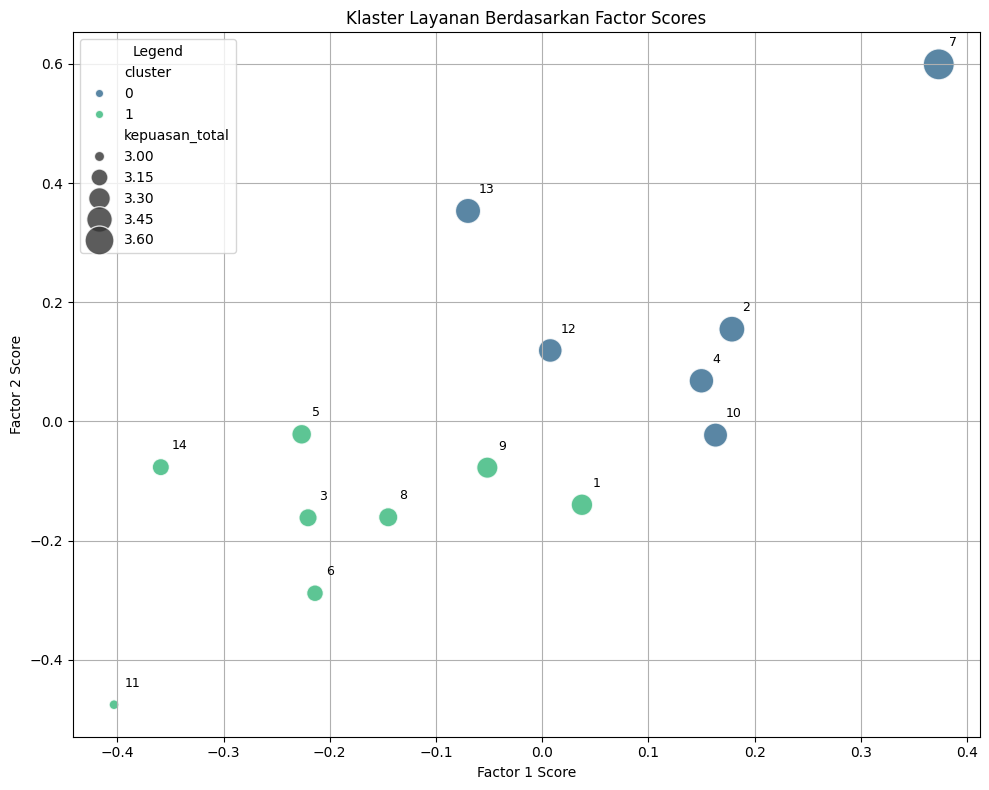

In [ ]:
# --- Plot Hasil Clustering Berdasarkan Factor Scores ---

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='factor1_score',
    y='factor2_score',
    hue='cluster',
    size='kepuasan_total',
    sizes=(50, 500),
    data=df_cluster,
    palette='viridis',
    alpha=0.8
)

# Label nama layanan pada tiap titik
for i, row in df_cluster.iterrows():
    plt.text(
        row['factor1_score'] + 0.01,
        row['factor2_score'] + 0.03,
        row['no_layanan'],
        fontsize=9
    )

plt.title('Klaster Layanan Berdasarkan Factor Scores')
plt.xlabel('Factor 1 Score')
plt.ylabel('Factor 2 Score')
plt.grid(True)
plt.legend(title='Legend')
plt.tight_layout()
plt.show()

In [ ]:
# --- Ringkasan Klaster Berdasarkan Rata-rata Variabel Utama ---

# Hitung rata-rata setiap variabel per klaster
cluster_summary = df_cluster.groupby('cluster')[['kepuasan_total', 'factor1_score', 'factor2_score']].mean()

print("Rata-rata Kepuasan Total dan Factor Scores per Klaster:")
display(cluster_summary)

# Tampilkan layanan yang masuk ke masing-masing klaster
print("\nLayanan per Klaster:")
for cluster_id in sorted(df_cluster['cluster'].unique()):
    print(f"\nKlaster {cluster_id}:")
    services = df_cluster[df_cluster['cluster'] == cluster_id]['layanan'].tolist()
    print(services)

# --- Interpretasi Karakteristik Klaster ---

print("\n--- Interpretasi Karakteristik Klaster ---")

# Klaster 0
print("\nKlaster 0:")
print("  - Contoh layanan: Pelayanan Pasar, Jalan, Lalu Lintas & Penerangan, Perizinan, Persampahan, Kelurahan")
print(f"  - Rata-rata Kepuasan Total : {cluster_summary.loc[0, 'kepuasan_total']:.2f}")
print(f"  - Rata-rata Factor 1 Score : {cluster_summary.loc[0, 'factor1_score']:.2f}")
print(f"  - Rata-rata Factor 2 Score : {cluster_summary.loc[0, 'factor2_score']:.2f}")
print("  - Catatan: Klaster ini menunjukkan nilai relatif lebih rendah pada kepuasan dan kedua faktor, sehingga layanan di dalamnya berpotensi menjadi prioritas perbaikan.")

# Klaster 1
print("\nKlaster 1:")
print("  - Contoh layanan: Pelayanan Kesehatan Dasar, Hewan, Pendidikan, RSUD, Adminduk, Pembayaran Pajak, Damkar")
print(f"  - Rata-rata Kepuasan Total : {cluster_summary.loc[1, 'kepuasan_total']:.2f}")
print(f"  - Rata-rata Factor 1 Score : {cluster_summary.loc[1, 'factor1_score']:.2f}")
print(f"  - Rata-rata Factor 2 Score : {cluster_summary.loc[1, 'factor2_score']:.2f}")
print("  - Catatan: Klaster ini berada pada kisaran nilai sedang. Layanan-layanan di klaster ini umumnya memenuhi ekspektasi dasar namun tetap memiliki ruang untuk peningkatan.")

# Ringkasan
print("\n--- Ringkasan Keseluruhan ---")
print("Klaster 0: Menunjukkan kecenderungan nilai kepuasan serta faktor kualitas yang lebih rendah.")
print("Klaster 1: Mencerminkan kelompok layanan dengan nilai yang berada pada tingkat sedang/rata-rata.")

Rata-rata Kepuasan Total dan Factor Scores per Klaster:


,kepuasan_total,factor1_score,factor2_score
cluster,,,
0,3.466178,0.133749,0.211878
1,3.189438,-0.197763,-0.175170



Layanan per Klaster:

Klaster 0:
['Pelayanan Hewan', 'Pelayanan Pembayaran Pajak', 'Pelayanan Pemadam Kebakaran & Penyelamatan', 'Pelayanan Lanjutan RSUD', 'Pelayanan Pendidikan', 'Pelayanan Kartu Kuning']

Klaster 1:
['Pelayanan Kesehatan Dasar', 'Pelayanan Pasar', 'Pelayanan pada Kelurahan', 'Pelayanan Perizinan', 'Pelayanan Jalan', 'Pelayanan Persampahan & Limbah', 'Pelayanan Lalu Lintas & Penerangan', 'Pelayanan Administrasi Kependudukan']

--- Interpretasi Karakteristik Klaster ---

Klaster 0:
  - Contoh layanan: Pelayanan Pasar, Jalan, Lalu Lintas & Penerangan, Perizinan, Persampahan, Kelurahan
  - Rata-rata Kepuasan Total : 3.47
  - Rata-rata Factor 1 Score : 0.13
  - Rata-rata Factor 2 Score : 0.21
  - Catatan: Klaster ini menunjukkan nilai relatif lebih rendah pada kepuasan dan kedua faktor, sehingga layanan di dalamnya berpotensi menjadi prioritas perbaikan.

Klaster 1:
  - Contoh layanan: Pelayanan Kesehatan Dasar, Hewan, Pendidikan, RSUD, Adminduk, Pembayaran Pajak, Damkar

In [ ]:
# --- Persiapan Data untuk Analisis Word Cloud ---

# Ambil kolom teks awal
df_text_processing = df_preprocessed[['no_layanan', 'alasan', 'saran']].copy()

# Tambahkan informasi klaster
df_text_processing = pd.merge(
    df_text_processing,
    df_cluster[['no_layanan', 'cluster']],
    on='no_layanan',
    how='left'
)

print("DataFrame untuk analisis teks (alasan & saran) dengan informasi klaster:")
display(df_text_processing.head())

DataFrame untuk analisis teks (alasan & saran) dengan informasi klaster:


,no_layanan,alasan,saran,cluster
0,14,-,"Tingkatkan Ramah, Jujur, Terbuka terhadap pela...",1
1,1,-,-,1
2,1,-,-,1
3,8,"-Jalan banyak yang berlubang, rambu-rambu petu...",-Mekanisme kinerja dishub dan polantas tidak m...,1
4,4,-,Fasilitas ditingkatkan,0


In [ ]:
# --- Pembersihan Teks Dasar (Cleaning Tahap 1) ---

# Ganti '-' menjadi NaN lalu hilangkan spasi berlebih
df_text_processing['alasan'] = (
    df_text_processing['alasan']
    .replace('-', np.nan)
    .str.strip()
)
df_text_processing['saran'] = (
    df_text_processing['saran']
    .replace('-', np.nan)
    .str.strip()
)

# Hapus baris yang tidak memiliki teks di kedua kolom
df_text_processing.dropna(
    subset=['alasan', 'saran'],
    how='all',
    inplace=True
)

print("Data setelah pembersihan awal:")
display(df_text_processing.head())

Data setelah pembersihan awal:


,no_layanan,alasan,saran,cluster
0,14,NaN,"Tingkatkan Ramah, Jujur, Terbuka terhadap pela...",1
3,8,"-Jalan banyak yang berlubang, rambu-rambu petu...",-Mekanisme kinerja dishub dan polantas tidak m...,1
4,4,NaN,Fasilitas ditingkatkan,0
5,8,"lampu lalu lintas sudah memadai, namun sering ...",untuk dipertigaan seharusnya ada petugas dishu...,1
6,4,NaN,"Pelayanan, Fasilitas penunjang ditingkatkan",0


In [ ]:
# --- Preprocessing Teks untuk Word Cloud ---

# Pastikan NLTK stopwords tersedia
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Daftar stopword Bahasa Indonesia + tambahan
stop_words_id = set(stopwords.words('indonesian'))
stop_words_id.update(['nya', 'abc', 'pelayanan', 'layanan', 'lampu'])   # tambahan stopwords
# catatan: 'jalan' sengaja tidak ditambahkan (sesuai permintaan)

# Fungsi preprocessing teks
def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'-', ' ', text)          # ganti hyphen dengan spasi
    text = re.sub(r'\d+', '', text)         # hapus angka
    text = re.sub(r'[^a-z\s]', '', text)    # hapus karakter non alfabet
    tokens = text.split()

    # Hapus stopwords & kata terlalu pendek
    tokens = [w for w in tokens if w not in stop_words_id and len(w) > 2]

    # Hilangkan duplikasi kata dengan mempertahankan urutan pertama muncul
    seen = set()
    dedup = []
    for w in tokens:
        if w not in seen:
            seen.add(w)
            dedup.append(w)

    return " ".join(dedup)

print("Preprocess function berhasil disiapkan.")

Preprocess function berhasil disiapkan.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# --- Terapkan Preprocessing ke Kolom 'alasan' dan 'saran' ---

df_text_processing['alasan_processed'] = df_text_processing['alasan'].apply(preprocess_text)
df_text_processing['saran_processed'] = df_text_processing['saran'].apply(preprocess_text)

print("Kolom 'alasan_processed' dan 'saran_processed' berhasil dibuat dan diisi.")

# Tampilkan beberapa baris awal untuk pengecekan
display(df_text_processing[['alasan', 'alasan_processed',
                            'saran', 'saran_processed']].head())

Kolom 'alasan_processed' dan 'saran_processed' berhasil dibuat dan diisi.


,alasan,alasan_processed,saran,saran_processed
0,NaN,,"Tingkatkan Ramah, Jujur, Terbuka terhadap pela...",tingkatkan ramah jujur terbuka
3,"-Jalan banyak yang berlubang, rambu-rambu petu...",jalan berlubang rambu petunjuk bagus razia mob...,-Mekanisme kinerja dishub dan polantas tidak m...,mekanisme kinerja dishub polantas memadai prem...
4,NaN,,Fasilitas ditingkatkan,fasilitas ditingkatkan
5,"lampu lalu lintas sudah memadai, namun sering ...",lintas memadai macet,untuk dipertigaan seharusnya ada petugas dishu...,dipertigaan petugas dishub macet dijalan
6,NaN,,"Pelayanan, Fasilitas penunjang ditingkatkan",fasilitas penunjang ditingkatkan


In [ ]:
# --- Gabungkan Teks 'Alasan' per Klaster (unik) ---

df_alasan_unique = (
    df_text_processing[df_text_processing['alasan_processed'] != '']
    .drop_duplicates(subset=['cluster', 'alasan_processed'])
)

combined_alasan_per_cluster = (
    df_alasan_unique
    .groupby('cluster')['alasan_processed']
    .apply(lambda x: ' '.join(x))
    .reset_index()
)

# --- Gabungkan Teks 'Saran' per Klaster (unik) ---

df_saran_unique = (
    df_text_processing[df_text_processing['saran_processed'] != '']
    .drop_duplicates(subset=['cluster', 'saran_processed'])
)

combined_saran_per_cluster = (
    df_saran_unique
    .groupby('cluster')['saran_processed']
    .apply(lambda x: ' '.join(x))
    .reset_index()
)

In [ ]:
# --- Function to Generate Word Count DataFrame ---
def get_word_counts_df(text_data, num_words=30):
    if not text_data:
        return pd.DataFrame(columns=['Word', 'Count'])
    words = text_data.split()
    word_counts = Counter(words)
    return pd.DataFrame(word_counts.most_common(num_words), columns=['Word', 'Count'])


# --- Word Counts: Alasan & Saran per Cluster ---

# Cluster 0
alasan_c0_text = combined_alasan_per_cluster.query("cluster == 0")['alasan_processed'].iloc[0] \
                 if not combined_alasan_per_cluster.query("cluster == 0").empty else ""
df_alasan_c0_counts = get_word_counts_df(alasan_c0_text)
print("\n--- Top 30 Words for Alasan (Cluster 0) ---")
display(df_alasan_c0_counts)

saran_c0_text = combined_saran_per_cluster.query("cluster == 0")['saran_processed'].iloc[0] \
                if not combined_saran_per_cluster.query("cluster == 0").empty else ""
df_saran_c0_counts = get_word_counts_df(saran_c0_text)
print("\n--- Top 30 Words for Saran (Cluster 0) ---")
display(df_saran_c0_counts)


# Cluster 1
alasan_c1_text = combined_alasan_per_cluster.query("cluster == 1")['alasan_processed'].iloc[0] \
                 if not combined_alasan_per_cluster.query("cluster == 1").empty else ""
df_alasan_c1_counts = get_word_counts_df(alasan_c1_text)
print("\n--- Top 30 Words for Alasan (Cluster 1) ---")
display(df_alasan_c1_counts)

saran_c1_text = combined_saran_per_cluster.query("cluster == 1")['saran_processed'].iloc[0] \
                if not combined_saran_per_cluster.query("cluster == 1").empty else ""
df_saran_c1_counts = get_word_counts_df(saran_c1_text)
print("\n--- Top 30 Words for Saran (Cluster 1) ---")
display(df_saran_c1_counts)


--- Top 30 Words for Alasan (Cluster 0) ---


,Word,Count
0,puas,57
1,bagus,11
2,obat,11
3,banget,9
4,operasi,9
5,sakit,8
6,cepat,8
7,bpjs,8
8,prosedur,7
9,sekolah,6



--- Top 30 Words for Saran (Cluster 0) ---


,Word,Count
0,ditingkatkan,57
1,tingkatkan,43
2,bagus,36
3,cepat,28
4,pasien,26
5,pertahankan,23
6,sekolah,17
7,semoga,16
8,sarana,16
9,prasarana,15



--- Top 30 Words for Alasan (Cluster 1) ---


,Word,Count
0,puas,32
1,jalan,26
2,petugas,18
3,bagus,17
4,kadang,13
5,lintas,12
6,macet,12
7,ramah,12
8,sampah,9
9,cepat,9



--- Top 30 Words for Saran (Cluster 1) ---


,Word,Count
0,jalan,72
1,ditingkatkan,72
2,masyarakat,64
3,petugas,50
4,cepat,49
5,tingkatkan,47
6,semoga,41
7,bagus,33
8,online,33
9,diperbaiki,28


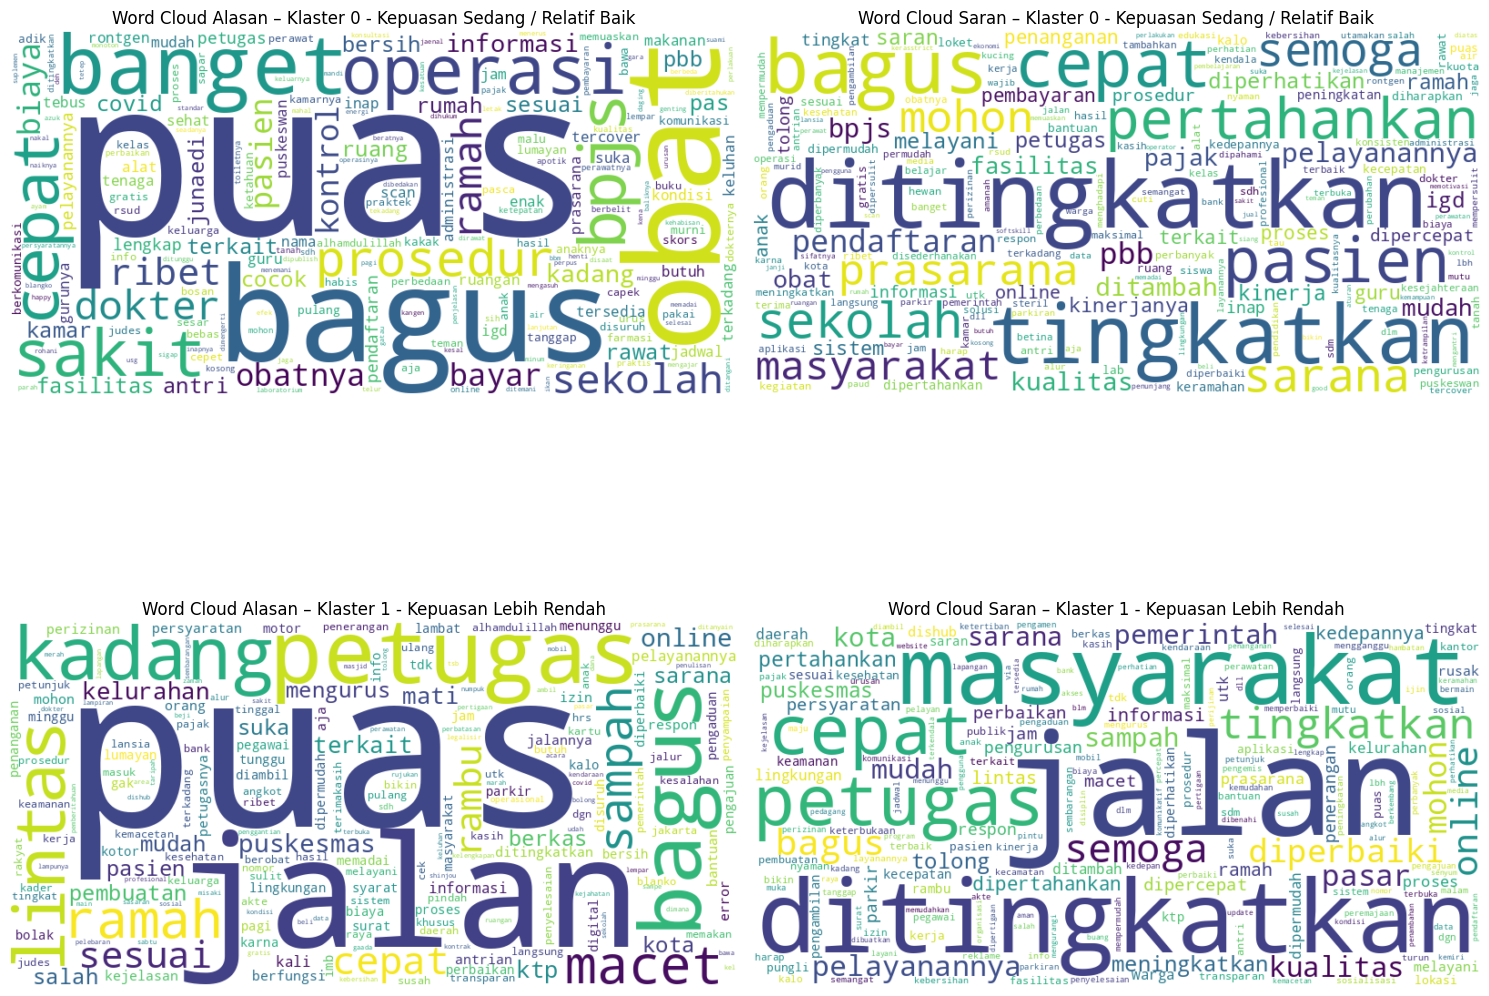

In [ ]:
# --- Word Cloud untuk Alasan & Saran per Klaster dengan Interpretasi ---

# Mapping interpretasi klaster (sesuai analisis)
cluster_labels = {
    0: "Klaster 0 - Kepuasan Sedang / Relatif Baik",
    1: "Klaster 1 - Kepuasan Lebih Rendah"
}

# Pastikan variabel cluster sudah ada
cluster_ids = sorted(df_cluster['cluster'].unique())
num_clusters = len(cluster_ids)

plt.figure(figsize=(15, 7 * num_clusters))  # Ukuran dinamis sesuai jumlah klaster

for i, cluster_id in enumerate(cluster_ids):

    # ===================
    #   WORD CLOUD ALASAN
    # ===================
    alasan_text = (
        combined_alasan_per_cluster
        .query("cluster == @cluster_id")['alasan_processed']
        .iloc[0]
        if not combined_alasan_per_cluster.query("cluster == @cluster_id").empty else ""
    )

    plt.subplot(num_clusters, 2, 2*i + 1)

    if alasan_text:
        wc_alasan = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False,
            random_state=108
        ).generate(alasan_text)
        plt.imshow(wc_alasan, interpolation='bilinear')
    else:
        plt.text(
            0.5, 0.5,
            f"Tidak ada data Alasan untuk {cluster_labels.get(cluster_id, f'Klaster {cluster_id}')}",
            ha='center', va='center',
            transform=plt.gca().transAxes
        )

    plt.title(f"Word Cloud Alasan – {cluster_labels.get(cluster_id)}")
    plt.axis('off')

    # =================
    #   WORD CLOUD SARAN
    # =================
    saran_text = (
        combined_saran_per_cluster
        .query("cluster == @cluster_id")['saran_processed']
        .iloc[0]
        if not combined_saran_per_cluster.query("cluster == @cluster_id").empty else ""
    )

    plt.subplot(num_clusters, 2, 2*i + 2)

    if saran_text:
        wc_saran = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False,
            random_state=108
        ).generate(saran_text)
        plt.imshow(wc_saran, interpolation='bilinear')
    else:
        plt.text(
            0.5, 0.5,
            f"Tidak ada data Saran untuk {cluster_labels.get(cluster_id, f'Klaster {cluster_id}')}",
            ha='center', va='center',
            transform=plt.gca().transAxes
        )

    plt.title(f"Word Cloud Saran – {cluster_labels.get(cluster_id)}")
    plt.axis('off')

plt.tight_layout()
plt.show()